# Coherent Power Overlay

Load a true live coherent snapshot and overlay the offline coherent validator replay mask produced from that exact live detection artifact.

In [27]:
from __future__ import annotations

from IPython import get_ipython

import importlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

_ = (json, subprocess, np, Image)

WORKSPACE_ROOT = Path('/home/sat3737/holoscan_demo_workspace')
NOTEBOOK_DIR = WORKSPACE_ROOT / 'holohub-dev' / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import coherant_power_signal_detection_helpers as cp_helpers
cp_helpers = importlib.reload(cp_helpers)

plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['image.cmap'] = 'viridis'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
resolved_sources = cp_helpers.resolve_latest_coherent_overlay_sources(
    prefer_reference_debug=True
)

snapshot_json_path = resolved_sources["metadata_path"]
tensor_path = resolved_sources.get("tensor_path")
summary_path = resolved_sources["summary_path"]
validator_output_dir = resolved_sources["output_dir"]
run_command = resolved_sources.get("run_command")
tensor_axis_order_override = None
run_validator = False

print(
    {
        "mode": resolved_sources["mode"],
        "snapshot_json_path": str(snapshot_json_path),
        "tensor_path": None if tensor_path is None else str(tensor_path),
        "validator_output_dir": str(validator_output_dir),
        "summary_path": str(summary_path),
        "run_command": run_command,
        "tensor_axis_order_override": tensor_axis_order_override,
    }
)

{'mode': 'live_reference_debug', 'snapshot_json_path': '/tmp/coherent_power_snapshots/live_reference_debug/coherent_power_snapshot_ch0_f1_1776990171192_20480x512.json', 'tensor_path': None, 'validator_output_dir': '/tmp/coherent_power_snapshots/live_reference_debug', 'summary_path': '/tmp/coherent_power_snapshots/live_reference_debug/coherent_power_snapshot_ch0_f1_1776990171192_20480x512.json', 'run_command': None, 'tensor_axis_order_override': None}


In [29]:
print("Command:")
print(run_command)

if run_validator and run_command:
    subprocess.run(run_command, shell=True, check=True)
elif run_validator:
    print("No rerun command is available for the auto-resolved live reference debug bundle.")
else:
    print("Set run_validator = True only when the resolved source provides a rerun command.")

Command:
None
Set run_validator = True only when the resolved source provides a rerun command.


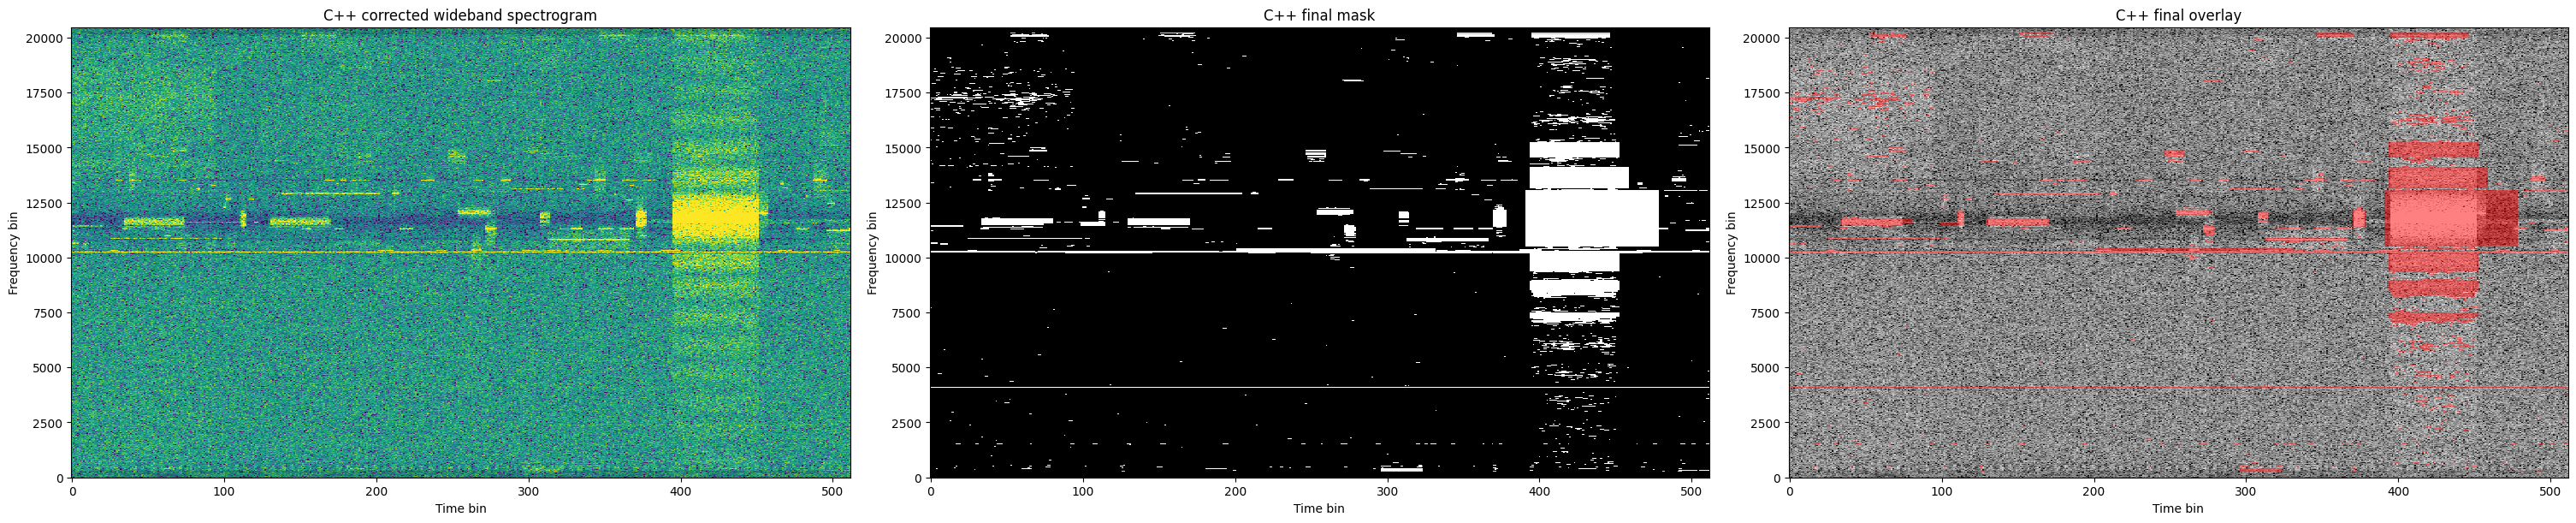

{'pipeline_mode_effective': 'operator_live_reference_debug',
 'display_transposed': False,
 'main_plot_transposed': False,
 'tensor_axis_order': 'frequency_time',
 'power_assist_mode': None,
 'merged_noise_floor_db': None,
 'tensor_analysis_shape': (20480, 512),
 'tensor_display_shape': (20480, 512),
 'corrected_db_raw_shape': (20480, 512),
 'raw_projected_mask_raw_shape': None,
 'cpp_merged_coherence_shape': None,
 'cpp_merged_power_shape': None,
 'cpp_merged_score_shape': None,
 'display_coherence_shape': None,
 'active_chunk_bandwidth_mhz': 37.5,
 'active_chunk_overlap_mhz': 2.0,
 'chunk_count_python': None,
 'ignore_bins_per_side': 287,
 'merged_box_count_python': None,
 'grouped_box_count_cpp': None,
 'grouped_boxes_cpp_loaded': 0,
 'tensor_snapshot_available': False,
 'summary': {'metadata_path': '/tmp/coherent_power_snapshots/live_reference_debug/coherent_power_snapshot_ch0_f1_1776990171192_20480x512.json',
  'pipeline_mode_effective': 'operator_live_reference_debug',
  'backend

In [30]:
overlay_context = cp_helpers.load_offline_coherent_overlay_context(
    tensor_path=tensor_path,
    summary_path=summary_path,
    tensor_axis_order_override=tensor_axis_order_override,
    prefer_reference_debug_bundle=True,
)

_ = cp_helpers.plot_cpp_offline_validation_maps(overlay_context, figsize=(30, 6))
plt.show()

overlay_context["diagnostics"]

In [31]:
# python_pipeline_result = cp_helpers.run_coherent_power_pipeline(
#     overlay_context["input_record"],
#     overlay_context["active_cfg"],
# )

# _ = cp_helpers.plot_raw_detection_debug(python_pipeline_result, figsize=(26, 5))
# plt.show()

{'latest_mask_path': '/tmp/coherent_power_masks/performance_route_probe/coherent_power_mask_ch0_f8_1776992688765_20480x512.pgm', 'shape': (20480, 512), 'nonzero_pixels': 0, 'fill_ratio': 0.0}


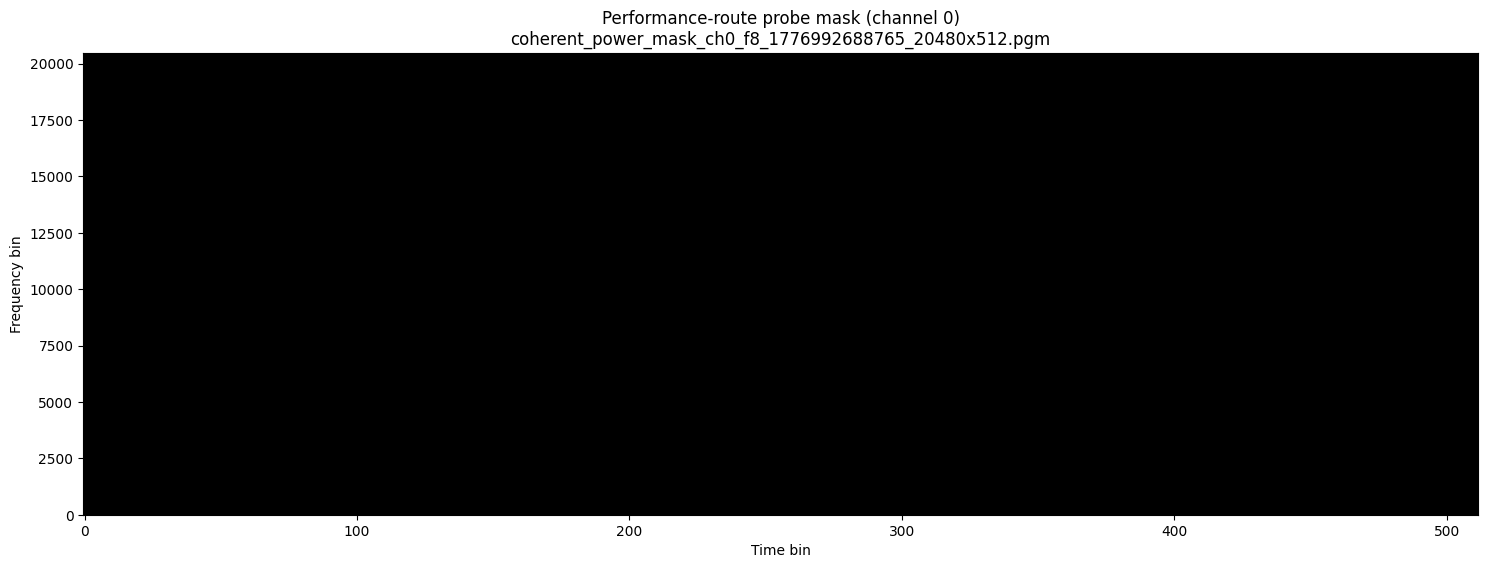

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

mask_root = Path("/tmp/coherent_power_masks/performance_route_probe")
mask_candidates = sorted(
    mask_root.glob("coherent_power_mask_ch0_f*_*.pgm"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

if not mask_candidates:
    raise FileNotFoundError(f"No channel 0 probe masks found under {mask_root}")

latest_mask_path = mask_candidates[0]
mask_image = np.array(Image.open(latest_mask_path))

print(
    {
        "latest_mask_path": str(latest_mask_path),
        "shape": tuple(int(v) for v in mask_image.shape),
        "nonzero_pixels": int((mask_image > 0).sum()),
        "fill_ratio": float((mask_image > 0).mean()),
    }
)

plt.figure(figsize=(18, 6))
plt.imshow(mask_image, aspect="auto", origin="lower", cmap="gray")
plt.title(f"Performance-route probe mask (channel 0)\n{latest_mask_path.name}")
plt.xlabel("Time bin")
plt.ylabel("Frequency bin")
plt.show()